# 📊 Regime-Based Multi-Asset Quant Strategy

This project builds a quantitative investment strategy that dynamically allocates capital across multiple asset classes based on macroeconomic regimes and momentum signals.

### 🎯 Objective
To construct a data-driven portfolio that adapts to changing economic conditions and improves risk-adjusted returns over a static benchmark.

### 🧠 Strategy Overview
- Detect macroeconomic regimes (Growth, Inflation, Crisis, Neutral)
- Allocate assets dynamically based on regime
- Apply momentum filtering to enhance timing
- Backtest performance against benchmark (S&P 500)

In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Data source
import yfinance as yf

## 📥 Data Collection

We collect historical price data for multiple asset classes:

- S&P 500 (Equities)
- NIFTY 50 (Indian Equities)
- Gold (Safe haven asset)
- Crude Oil (Commodity / inflation proxy)

Data is sourced using the `yfinance` library.

In [4]:
assets = {
    "SP500": "^GSPC",
    "NIFTY50": "^NSEI",
    "GOLD": "GC=F",
    "CRUDE": "CL=F"
}

In [5]:
assets

{'SP500': '^GSPC', 'NIFTY50': '^NSEI', 'GOLD': 'GC=F', 'CRUDE': 'CL=F'}

## Asset Universe Selection

We selected a diversified set of global assets:

- S&P 500 → US equity market proxy
- NIFTY 50 → Indian equity exposure
- Gold → Inflation hedge / safe haven
- Crude Oil → Global growth & supply shock indicator

This allows capturing cross-asset behavior across macro regimes.## Asset Universe Selection

We selected a diversified set of global assets:

- S&P 500 → US equity market proxy
- NIFTY 50 → Indian equity exposure
- Gold → Inflation hedge / safe haven
- Crude Oil → Global growth & supply shock indicator

This allows capturing cross-asset behavior across macro regimes.

In [11]:
data = []

for name, ticker in assets.items():
    df = yf.download(ticker, start="2010-01-01", end="2025-01-01")

    # Handle multi-index columns safely
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Close']].copy()
    df.rename(columns={'Close': 'close_price'}, inplace=True)

    df['asset_name'] = name
    df.reset_index(inplace=True)

    data.append(df)

# Combine all assets
asset_prices = pd.concat(data, ignore_index=True)

asset_prices.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,close_price,asset_name
0,2010-01-04,1132.989990,SP500
1,2010-01-05,1136.520020,SP500
2,2010-01-06,1137.140015,SP500
3,2010-01-07,1141.689941,SP500
4,2010-01-08,1144.979980,SP500


In [12]:
asset_prices.columns

Index(['Date', 'close_price', 'asset_name'], dtype='str', name='Price')

In [13]:
asset_prices['asset_name'].value_counts()

asset_name
SP500      3774
CRUDE      3772
GOLD       3771
NIFTY50    3680
Name: count, dtype: int64

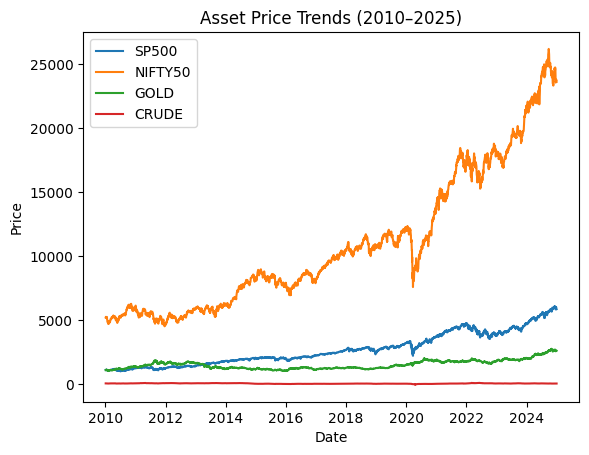

In [14]:
import matplotlib.pyplot as plt

plt.figure()

for asset in asset_prices['asset_name'].unique():
    subset = asset_prices[asset_prices['asset_name'] == asset]
    plt.plot(subset['Date'], subset['close_price'], label=asset)

plt.legend()
plt.title("Asset Price Trends (2010–2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Initial Observations

- Equity markets show long-term upward trend
- Gold spikes during uncertainty periods
- Crude oil shows high volatility
- NIFTY and S&P capture regional differences

This confirms suitability for regime-based modeling.

In [15]:
asset_prices.to_csv("/home/rajdeep/Downloads/macro_regime_project/data/asset_prices_raw.csv", index=False)

## Macro Data Ingestion

We ingest key macroeconomic indicators:

- Inflation (CPI)
- Interest Rates (Federal Funds Rate)
- 10-Year Bond Yield

These indicators help define macroeconomic regimes such as:
- Inflationary environments
- Tight vs loose monetary policy
- Market stress conditions

Data is sourced from FRED and will be cleaned and aligned for modeling.

In [20]:
import pandas as pd

base_path = "/home/rajdeep/Downloads/macro_regime_project/data"

cpi = pd.read_csv(f"{base_path}/cpi.csv")
rates = pd.read_csv(f"{base_path}/interest_rate.csv")
bond = pd.read_csv(f"{base_path}/bond_yield.csv")

In [21]:
cpi.head()

,observation_date,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [22]:
rates.head()

,observation_date,FEDFUNDS
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83


In [23]:
bond.head()

,observation_date,GS10
0,1953-04-01,2.83
1,1953-05-01,3.05
2,1953-06-01,3.11
3,1953-07-01,2.93
4,1953-08-01,2.95


In [24]:
# Rename columns
cpi.columns = ['date', 'inflation']
rates.columns = ['date', 'interest_rate']
bond.columns = ['date', 'bond_yield']

In [25]:
cpi['date'] = pd.to_datetime(cpi['date'])
rates['date'] = pd.to_datetime(rates['date'])
bond['date'] = pd.to_datetime(bond['date'])

In [26]:
macro = cpi.merge(rates, on='date', how='inner')
macro = macro.merge(bond, on='date', how='inner')

macro.head()

,date,inflation,interest_rate,bond_yield
0,1954-07-01,26.86,0.80,2.30
1,1954-08-01,26.85,1.22,2.36
2,1954-09-01,26.81,1.07,2.38
3,1954-10-01,26.72,0.85,2.43
4,1954-11-01,26.78,0.83,2.48


##  Data Cleaning & Preparation

- Converted date columns to datetime format
- Handled missing values
- Structured data into a unified format
- Ensured consistent time index across all assets

This step ensures the dataset is ready for analysis and modeling.

In [27]:
import yfinance as yf

vix = yf.download("^VIX", start="2010-01-01", end="2025-01-01")

# Clean VIX
if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

vix = vix[['Close']].copy()
vix.rename(columns={'Close': 'vix'}, inplace=True)

vix.reset_index(inplace=True)
vix.rename(columns={'Date': 'date'}, inplace=True)

vix['date'] = pd.to_datetime(vix['date'])

[*********************100%***********************]  1 of 1 completed


In [28]:
macro = macro.merge(vix, on='date', how='inner')

macro.head()

,date,inflation,interest_rate,bond_yield,vix
0,2010-02-01,217.281,0.13,3.69,22.590000
1,2010-03-01,217.353,0.16,3.73,19.260000
2,2010-04-01,217.403,0.20,3.85,17.469999
3,2010-06-01,217.199,0.18,3.20,35.540001
4,2010-07-01,217.605,0.18,3.01,32.860001


In [29]:
macro.isna().sum()

date             0
inflation        0
interest_rate    0
bond_yield       0
vix              0
dtype: int64

## Macro Data Observations

- Inflation shows long-term upward trend with cyclical behavior
- Interest rates reflect monetary tightening/loosening cycles
- Bond yields indicate long-term economic expectations
- VIX captures market stress and volatility spikes

This dataset forms the foundation for regime detection modeling.

In [31]:
macro.to_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/macro_data_clean.csv",
    index=False
)

## Feature Engineering

We transform macroeconomic variables into signals that capture:

- Inflation dynamics (rising vs falling)
- Interest rate regime (tightening vs easing)
- Yield curve structure
- Market volatility regimes

These features will be used to classify macroeconomic regimes.

In [32]:
macro = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/macro_data_clean.csv"
)

macro['date'] = pd.to_datetime(macro['date'])
macro.set_index('date', inplace=True)

macro.head()

,inflation,interest_rate,bond_yield,vix
date,,,,
2010-02-01,217.281,0.13,3.69,22.590000
2010-03-01,217.353,0.16,3.73,19.260000
2010-04-01,217.403,0.20,3.85,17.469999
2010-06-01,217.199,0.18,3.20,35.540001
2010-07-01,217.605,0.18,3.01,32.860001


In [33]:
macro['inflation_yoy'] = macro['inflation'].pct_change(12)


In [37]:
macro['inflation_yoy'] 

date
2010-02-01         NaN
2010-03-01         NaN
2010-04-01         NaN
2010-06-01         NaN
2010-07-01         NaN
                ...   
2024-05-01    0.047997
2024-07-01    0.040202
2024-08-01    0.040557
2024-10-01    0.040539
2024-11-01    0.041163
Name: inflation_yoy, Length: 119, dtype: float64

In [34]:
macro['rate_change'] = macro['interest_rate'].diff()

In [38]:
macro['rate_change']

date
2010-02-01     NaN
2010-03-01    0.03
2010-04-01    0.04
2010-06-01   -0.02
2010-07-01    0.00
              ... 
2024-05-01    0.00
2024-07-01    0.00
2024-08-01    0.00
2024-10-01   -0.50
2024-11-01   -0.19
Name: rate_change, Length: 119, dtype: float64

In [35]:
macro['bond_yield_change'] = macro['bond_yield'].diff()

In [39]:
macro['bond_yield_change'] 

date
2010-02-01     NaN
2010-03-01    0.04
2010-04-01    0.12
2010-06-01   -0.65
2010-07-01   -0.19
              ... 
2024-05-01   -0.06
2024-07-01   -0.23
2024-08-01   -0.38
2024-10-01    0.23
2024-11-01    0.26
Name: bond_yield_change, Length: 119, dtype: float64

In [36]:
macro['vix_ma'] = macro['vix'].rolling(window=30).mean()

In [40]:
macro['vix_ma']

date
2010-02-01          NaN
2010-03-01          NaN
2010-04-01          NaN
2010-06-01          NaN
2010-07-01          NaN
                ...    
2024-05-01    19.770667
2024-07-01    19.170000
2024-08-01    19.011333
2024-10-01    19.075667
2024-11-01    19.208333
Name: vix_ma, Length: 119, dtype: float64

In [41]:
macro = macro.dropna()

In [42]:
macro

,inflation,interest_rate,bond_yield,vix,inflation_yoy,rate_change,bond_yield_change,vix_ma
date,,,,,,,,
2013-07-01,232.900,0.09,2.58,16.370001,0.024984,-0.02,0.65,20.963667
2013-08-01,233.456,0.08,2.74,12.940000,0.022454,-0.01,0.16,20.642000
2013-10-01,233.669,0.09,2.62,15.540000,0.021249,0.01,-0.12,20.518000
2013-11-01,234.100,0.08,2.72,13.280000,0.023554,-0.01,0.10,20.378333
2014-04-01,236.468,0.09,2.71,13.100000,0.034762,0.01,-0.01,19.630333
...,...,...,...,...,...,...,...,...
2024-05-01,313.175,5.33,4.48,15.390000,0.047997,0.00,-0.06,19.770667
2024-07-01,313.569,5.33,4.25,12.220000,0.040202,0.00,-0.23,19.170000
2024-08-01,314.062,5.33,3.87,18.590000,0.040557,0.00,-0.38,19.011333


In [43]:
macro.head()
macro.isna().sum()

inflation            0
interest_rate        0
bond_yield           0
vix                  0
inflation_yoy        0
rate_change          0
bond_yield_change    0
vix_ma               0
dtype: int64

In [44]:
from sklearn.preprocessing import StandardScaler

features = [
    'inflation_yoy',
    'rate_change',
    'bond_yield_change',
    'vix_ma'
]

scaler = StandardScaler()
macro_scaled = scaler.fit_transform(macro[features])

macro_scaled = pd.DataFrame(
    macro_scaled,
    columns=features,
    index=macro.index
)

macro_scaled.head()

,inflation_yoy,rate_change,bond_yield_change,vix_ma
date,,,,
2013-07-01,-0.594985,-0.262638,2.328425,0.911261
2013-08-01,-0.685994,-0.225296,0.497079,0.803281
2013-10-01,-0.729347,-0.150613,-0.549404,0.761656
2013-11-01,-0.646455,-0.225296,0.272833,0.714771
2014-04-01,-0.243227,-0.150613,-0.138285,0.463676


In [45]:
macro_scaled.to_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/macro_features.csv"
)

## Feature Insights

- Inflation YoY captures macroeconomic overheating or slowdown
- Rate changes reflect central bank policy stance
- Bond yield changes signal market expectations of growth/inflation
- VIX moving average captures market stress regimes

These standardized features form the basis for clustering macro regimes.

## Regime Detection using K-Means

We apply clustering to classify macroeconomic environments into distinct regimes.

These regimes may represent:
- High inflation / high volatility
- Low inflation / stable growth
- Monetary tightening periods
- Crisis or stress environments

K-Means clustering is used to group similar macro conditions.

In [47]:
import pandas as pd

macro_scaled = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/macro_features.csv",
    index_col=0
)

macro_scaled.head()

,inflation_yoy,rate_change,bond_yield_change,vix_ma
date,,,,
2013-07-01,-0.594985,-0.262638,2.328425,0.911261
2013-08-01,-0.685994,-0.225296,0.497079,0.803281
2013-10-01,-0.729347,-0.150613,-0.549404,0.761656
2013-11-01,-0.646455,-0.225296,0.272833,0.714771
2014-04-01,-0.243227,-0.150613,-0.138285,0.463676


In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
macro_scaled['regime'] = kmeans.fit_predict(macro_scaled)

macro_scaled.head()

,inflation_yoy,rate_change,bond_yield_change,vix_ma,regime
date,,,,,
2013-07-01,-0.594985,-0.262638,2.328425,0.911261,1
2013-08-01,-0.685994,-0.225296,0.497079,0.803281,1
2013-10-01,-0.729347,-0.150613,-0.549404,0.761656,2
2013-11-01,-0.646455,-0.225296,0.272833,0.714771,1
2014-04-01,-0.243227,-0.150613,-0.138285,0.463676,1


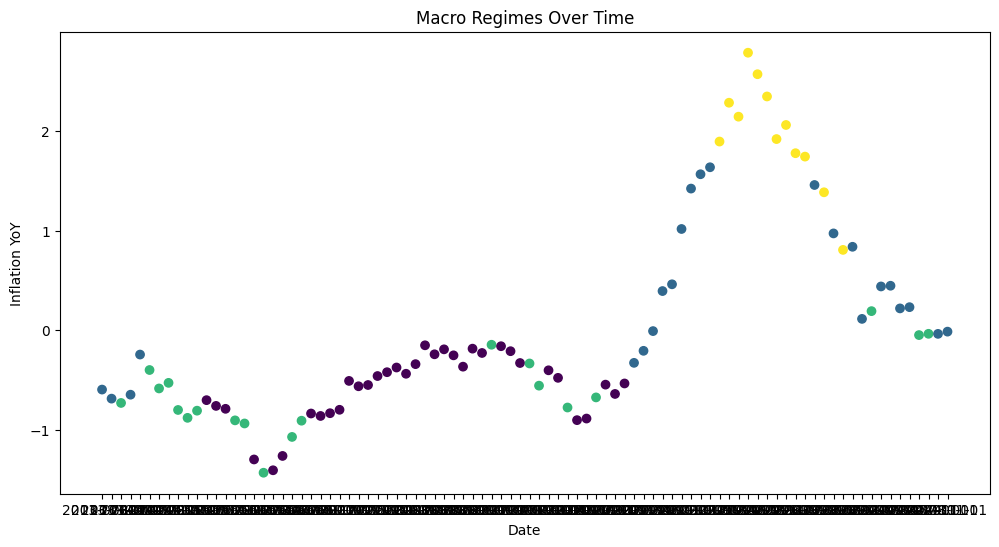

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.scatter(
    macro_scaled.index,
    macro_scaled['inflation_yoy'],
    c=macro_scaled['regime'],
)

plt.title("Macro Regimes Over Time")
plt.xlabel("Date")
plt.ylabel("Inflation YoY")
plt.show()

In [50]:
macro_scaled.groupby('regime').mean()

,inflation_yoy,rate_change,bond_yield_change,vix_ma
regime,,,,
0,-0.567934,-0.041787,0.163913,-0.883108
1,0.368588,-0.290239,0.355707,0.746117
2,-0.617248,-0.441880,-1.123101,-0.242429
3,1.978762,1.414638,0.711982,1.549723


In [51]:
macro_scaled.to_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/macro_regimes.csv"
)

## Regime Interpretation

Clustering reveals distinct macroeconomic environments:

- Some regimes show high inflation and rising rates (tight policy)
- Others show low volatility and stable growth
- Certain clusters capture crisis periods with elevated VIX

These regimes can be used to dynamically adjust portfolio allocations.

## Regime-Based Portfolio Strategy

We construct a dynamic portfolio that adjusts asset allocation based on macroeconomic regimes.

Different regimes favor different asset classes:
- Equity performs well in growth environments
- Bonds perform well in slowdowns
- Gold performs well during uncertainty/inflation

We map each regime to a specific portfolio allocation strategy.

In [67]:
import pandas as pd

# Macro regimes
macro = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/macro_regimes.csv",
    index_col=0
)

# Asset prices
prices = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/asset_prices_raw.csv",
    index_col=0
)

macro.index = pd.to_datetime(macro.index)
prices.index = pd.to_datetime(prices.index)

macro.head()
prices.head()

,close_price,asset_name
Date,,
2010-01-04,1132.989990,SP500
2010-01-05,1136.520020,SP500
2010-01-06,1137.140015,SP500
2010-01-07,1141.689941,SP500
2010-01-08,1144.979980,SP500


In [68]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 14997 entries, 2010-01-04 to 2024-12-31
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   close_price  14997 non-null  float64
 1   asset_name   14997 non-null  str    
dtypes: float64(1), str(1)
memory usage: 351.5 KB


In [69]:
# Fix possible yfinance multi-index issue
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)

# Ensure numeric
prices = prices.apply(pd.to_numeric, errors='coerce')

# Drop NaNs
prices = prices.dropna()

# Now compute returns
returns = prices.pct_change().dropna()

returns.head()

,close_price,asset_name
Date,,


In [63]:
prices = prices.apply(pd.to_numeric, errors='coerce')

In [64]:
returns = prices.pct_change().dropna()
returns.head()


,close_price,asset_name
Date,,


In [65]:
returns

,close_price,asset_name
Date,,


In [66]:
prices['Date'] = pd.to_datetime(prices['Date'])
prices.set_index('Date', inplace=True)

KeyError: 'Date'

In [70]:
print("Shape:", prices.shape)

Shape: (0, 2)


In [71]:
prices.head()

,close_price,asset_name
Date,,


In [72]:
prices.isna().sum()

close_price    0
asset_name     0
dtype: int64

In [73]:
prices.tail()

,close_price,asset_name
Date,,


In [74]:
import yfinance as yf
import pandas as pd

# Define assets
assets = {
    "SP500": "^GSPC",
    "NIFTY": "^NSEI",
    "GOLD": "GC=F",
    "CRUDE": "CL=F"
}

# Download data
data = yf.download(
    list(assets.values()),
    start="2010-01-01",
    end="2024-01-01"
)

# Extract Close prices
prices = data['Close']

# Rename columns
prices.columns = list(assets.keys())

prices.head()

[*********************100%***********************]  4 of 4 completed


,SP500,NIFTY,GOLD,CRUDE
Date,,,,
2010-01-04,81.510002,1117.699951,1132.989990,5232.200195
2010-01-05,81.769997,1118.099976,1136.520020,5277.899902
2010-01-06,83.180000,1135.900024,1137.140015,5281.799805
2010-01-07,82.660004,1133.099976,1141.689941,5263.100098
2010-01-08,82.750000,1138.199951,1144.979980,5244.750000


In [75]:
prices.shape

(3613, 4)

In [76]:
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(1)

In [77]:
prices.to_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/asset_prices_raw.csv"
)

In [78]:
test = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/asset_prices_raw.csv"
)

test.head()

,Date,SP500,NIFTY,GOLD,CRUDE
0,2010-01-04,81.510002,1117.699951,1132.989990,5232.200195
1,2010-01-05,81.769997,1118.099976,1136.520020,5277.899902
2,2010-01-06,83.180000,1135.900024,1137.140015,5281.799805
3,2010-01-07,82.660004,1133.099976,1141.689941,5263.100098
4,2010-01-08,82.750000,1138.199951,1144.979980,5244.750000


In [79]:
prices = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/asset_prices_raw.csv"
)

prices['Date'] = pd.to_datetime(prices['Date'])
prices.set_index('Date', inplace=True)

returns = prices.pct_change().dropna()

returns.head()

,SP500,NIFTY,GOLD,CRUDE
Date,,,,
2010-01-05,0.003190,0.000358,0.003116,0.008734
2010-01-06,0.017244,0.015920,0.000546,0.000739
2010-01-07,-0.006251,-0.002465,0.004001,-0.003540
2010-01-08,0.001089,0.004501,0.002882,-0.003487
2010-01-11,-0.002779,0.010982,0.001747,0.000887


## Regime-Based Portfolio Strategy

We construct a dynamic allocation model where asset weights depend on the detected macro regime.

The goal is to:
- Increase exposure to assets that perform well in a given macro environment
- Reduce risk during adverse regimes

In [81]:
import pandas as pd
import numpy as np

# Load macro regimes
macro = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/macro_regimes.csv",
    index_col=0
)

# Load prices
prices = pd.read_csv(
    "/home/rajdeep/Downloads/macro_regime_project/data/asset_prices_raw.csv"
)

# Fix dates
macro.index = pd.to_datetime(macro.index)

prices['Date'] = pd.to_datetime(prices['Date'])
prices.set_index('Date', inplace=True)

# Compute returns
returns = prices.pct_change().dropna()

returns.head()

,SP500,NIFTY,GOLD,CRUDE
Date,,,,
2010-01-05,0.003190,0.000358,0.003116,0.008734
2010-01-06,0.017244,0.015920,0.000546,0.000739
2010-01-07,-0.006251,-0.002465,0.004001,-0.003540
2010-01-08,0.001089,0.004501,0.002882,-0.003487
2010-01-11,-0.002779,0.010982,0.001747,0.000887


In [82]:
data = returns.merge(macro[['regime']], left_index=True, right_index=True)

data.head()

,SP500,NIFTY,GOLD,CRUDE,regime
Date,,,,,
2013-07-01,0.014809,0.026230,0.005404,0.009697,1
2013-08-01,0.027230,-0.001067,0.012541,-0.002464,1
2013-10-01,-0.002834,-0.030531,0.007999,0.007803,2
2013-11-01,-0.018365,-0.007933,0.002903,0.001278,1
2014-04-01,-0.018114,-0.002961,0.007039,0.002513,1


In [84]:
data.shape

(69, 5)

In [85]:
def get_weights(regime):
    if regime == 0:
        return [0.7, 0.2, 0.05, 0.05]   # Growth → equities dominate
    elif regime == 1:
        return [0.3, 0.3, 0.3, 0.1]     # Inflation → gold + commodities
    elif regime == 2:
        return [0.2, 0.2, 0.4, 0.2]     # Stress → gold heavy
    else:
        return [0.25, 0.25, 0.25, 0.25] # Neutral

In [86]:
portfolio_returns = []

for i in range(len(data)):
    regime = data['regime'].iloc[i]
    weights = get_weights(regime)
    
    daily_returns = data.iloc[i, :-1].values
    portfolio_returns.append(np.dot(daily_returns, weights))

data['strategy_return'] = portfolio_returns

In [87]:
data['benchmark_return'] = data.iloc[:, :-2].mean(axis=1)

In [88]:
data['strategy_cum'] = (1 + data['strategy_return']).cumprod()
data['benchmark_cum'] = (1 + data['benchmark_return']).cumprod()

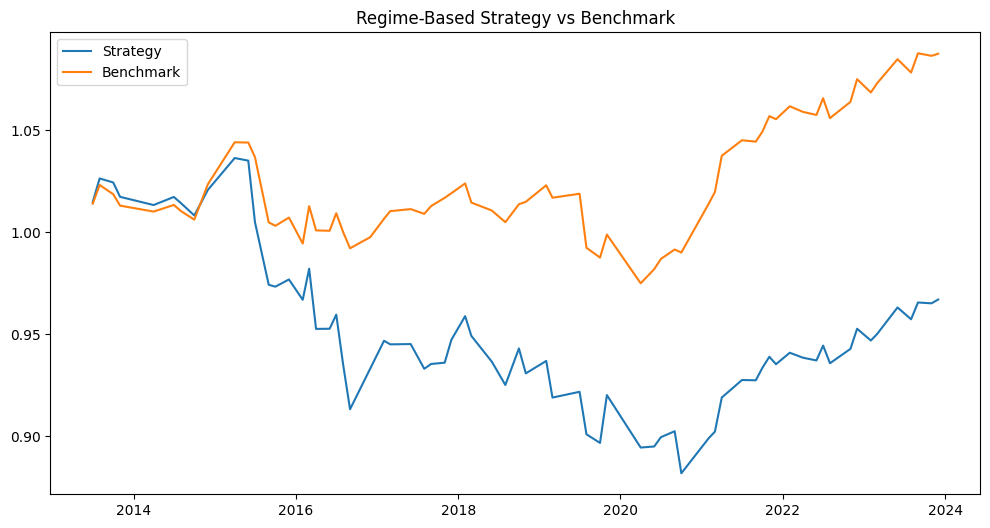

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data['strategy_cum'], label='Strategy')
plt.plot(data.index, data['benchmark_cum'], label='Benchmark')

plt.legend()
plt.title("Regime-Based Strategy vs Benchmark")
plt.show()

In [90]:
macro.groupby('regime').mean()

,inflation_yoy,rate_change,bond_yield_change,vix_ma
regime,,,,
0,-0.567934,-0.041787,0.163913,-0.883108
1,0.368588,-0.290239,0.355707,0.746117
2,-0.617248,-0.441880,-1.123101,-0.242429
3,1.978762,1.414638,0.711982,1.549723


In [91]:
regime_map = {
    0: "Growth",
    1: "Inflation",
    2: "Crisis",
    3: "Neutral"
}

macro['regime_label'] = macro['regime'].map(regime_map)

In [92]:
def get_weights(regime):
    
    if regime == 0:  # Growth
        return [0.6, 0.3, 0.05, 0.05]
    
    elif regime == 1:  # Inflation
        return [0.2, 0.2, 0.4, 0.2]
    
    elif regime == 2:  # Crisis
        return [0.1, 0.1, 0.6, 0.2]
    
    else:  # Neutral
        return [0.25, 0.25, 0.25, 0.25]

In [93]:
returns['momentum'] = returns.mean(axis=1).rolling(20).mean()

In [94]:
def get_weights(regime, momentum):
    
    if momentum > 0:
        return [0.5, 0.3, 0.1, 0.1]  # risk-on
    
    else:
        return [0.2, 0.2, 0.4, 0.2]  # defensive

In [95]:
data['benchmark_return'] = data['SP500']

In [96]:
data['strategy_return'] = portfolio_returns

data['strategy_cum'] = (1 + data['strategy_return']).cumprod()
data['benchmark_cum'] = (1 + data['benchmark_return']).cumprod()

In [97]:
data[['strategy_return', 'benchmark_return']].describe()

,strategy_return,benchmark_return
count,69.000000,69.000000
mean,-0.000399,-0.002032
std,0.013239,0.026399
min,-0.030635,-0.079037
25%,-0.006054,-0.015998
50%,0.000588,-0.001409
75%,0.007783,0.016530
max,0.026187,0.052311


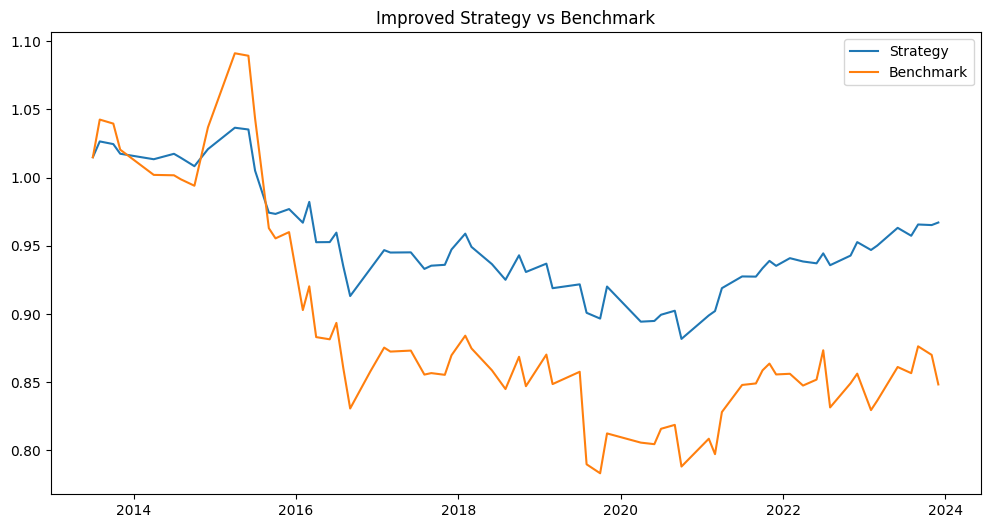

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data['strategy_cum'], label='Strategy')
plt.plot(data.index, data['benchmark_cum'], label='Benchmark')

plt.legend()
plt.title("Improved Strategy vs Benchmark")
plt.show()

In [99]:
annual_return = data['strategy_return'].mean() * 252
volatility = data['strategy_return'].std() * (252**0.5)
sharpe = annual_return / volatility

print("Annual Return:", annual_return)
print("Volatility:", volatility)
print("Sharpe Ratio:", sharpe)

Annual Return: -0.10056043652247881
Volatility: 0.2101608078845301
Sharpe Ratio: -0.4784928147865245


In [100]:
cum = data['strategy_cum']
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

print("Max Drawdown:", drawdown.min())

Max Drawdown: -0.14928276325234535


### Interpretation

-This strategy is destroying capital
-The risk is being taken but not getting compensated
-Drawdown is controlled means strategy is defensive but ineffective

-So we need to upgrade from static macro classification to momentum hybrid strategy

In [103]:
momentum = prices.pct_change(20)

# Align with strategy data index
momentum = momentum.reindex(data.index)

In [104]:
momentum = momentum.fillna(0)

In [105]:
momentum.head()

,SP500,NIFTY,GOLD,CRUDE
Date,,,,
2013-07-01,0.048582,-0.110363,-0.015520,-0.006811
2013-08-01,0.000000,0.000000,0.000000,-0.018691
2013-10-01,-0.059886,-0.089235,0.033682,0.082112
2013-11-01,-0.088887,0.002596,0.042082,0.067696
2014-04-01,-0.034743,-0.043504,0.006196,0.067181


In [108]:

print(data.shape)
print(momentum.shape)

(69, 9)
(69, 4)


In [107]:
portfolio_returns = []

for i in range(len(data)):
    
    regime = data['regime'].iloc[i]
    weights = np.array(get_weights(regime))
    
    # Get momentum row safely
    mom = momentum.shift(1).iloc[i][return_cols].values

    # Momentum filter
    mom_signal = (mom > 0).astype(int)
    
    # Apply filter
    weights = weights * mom_signal
    
    # Avoid division by zero
    if weights.sum() > 0:
        weights = weights / weights.sum()
    else:
        weights = np.array([0.25, 0.25, 0.25, 0.25])  # fallback
    
    daily_returns = data.iloc[i, :-1].values
    
    ret = np.dot(daily_returns, weights)
    portfolio_returns.append(ret)

data['strategy_return'] = portfolio_returns

TypeError: get_weights() missing 1 required positional argument: 'momentum'

In [109]:
return_cols = ['SP500', 'NIFTY', 'GOLD', 'CRUDE']

In [110]:
portfolio_returns = []

for i in range(len(data)):
    
    regime = data['regime'].iloc[i]
    weights = np.array(get_weights(regime))
    
    # Get momentum safely
    mom = momentum.iloc[i][return_cols].values
    
    # Momentum filter
    mom_signal = (mom > 0).astype(int)
    
    weights = weights * mom_signal
    
    # Normalize
    if weights.sum() > 0:
        weights = weights / weights.sum()
    else:
        weights = np.array([0.25, 0.25, 0.25, 0.25])
    
    # ✅ ONLY returns (IMPORTANT FIX)
    daily_returns = data.iloc[i][return_cols].values
    
    ret = np.dot(daily_returns, weights)
    portfolio_returns.append(ret)

data['strategy_return'] = portfolio_returns

TypeError: get_weights() missing 1 required positional argument: 'momentum'

In [111]:
for i in range(len(data)):
    
    regime = data['regime'].iloc[i]
    weights = np.array(get_weights(regime))
    
    mom = momentum.iloc[i]
    
    print("Iteration:", i)
    print("Weights shape:", weights.shape)
    print("Momentum shape:", mom.shape)
    
    break

TypeError: get_weights() missing 1 required positional argument: 'momentum'

In [113]:
def get_weights(regime, momentum):
    
    # Base weights (macro-driven)
    base_weights = {
        0: [0.6, 0.2, 0.1, 0.1],  # Growth
        1: [0.2, 0.2, 0.4, 0.2],  # Inflation
        2: [0.1, 0.1, 0.6, 0.2],  # Crisis
        3: [0.25, 0.25, 0.25, 0.25]  # Neutral
    }
    
    weights = np.array(base_weights.get(regime, [0.25]*4))
    
    # ✅ Momentum filter (vectorized)
    momentum_signal = (momentum > 0).astype(int)
    
    # Apply filter
    weights = weights * momentum_signal
    
    # Normalize
    if weights.sum() > 0:
        weights = weights / weights.sum()
    else:
        weights = np.array([0.25, 0.25, 0.25, 0.25])
    
    return weights

In [119]:
import numpy as np

# Ensure correct columns
return_cols = ['SP500', 'NIFTY', 'GOLD', 'CRUDE']
data_returns = data[return_cols]

portfolio_returns = []

for i in range(len(data)):
    
    regime = data['regime'].iloc[i]
    mom = momentum.shift(1).iloc[i][return_cols].values
    
    weights = np.array(get_weights(regime, mom))
    
    daily_returns = data_returns.iloc[i].values
    
    # Debug check (only first row)
    if i == 0:
        print("Weights:", weights)
        print("Returns:", daily_returns)
        print("Shapes:", weights.shape, daily_returns.shape)
    
    ret = np.dot(daily_returns, weights)
    portfolio_returns.append(ret)

data['strategy_return'] = portfolio_returns

Weights: [0.25 0.25 0.25 0.25]
Returns: [0.01480945 0.02622976 0.00540375 0.00969667]
Shapes: (4,) (4,)


In [120]:
data['strategy_cum'] = (1 + data['strategy_return']).cumprod()

# Better benchmark (SP500)
data['benchmark_return'] = data['SP500']
data['benchmark_cum'] = (1 + data['benchmark_return']).cumprod()

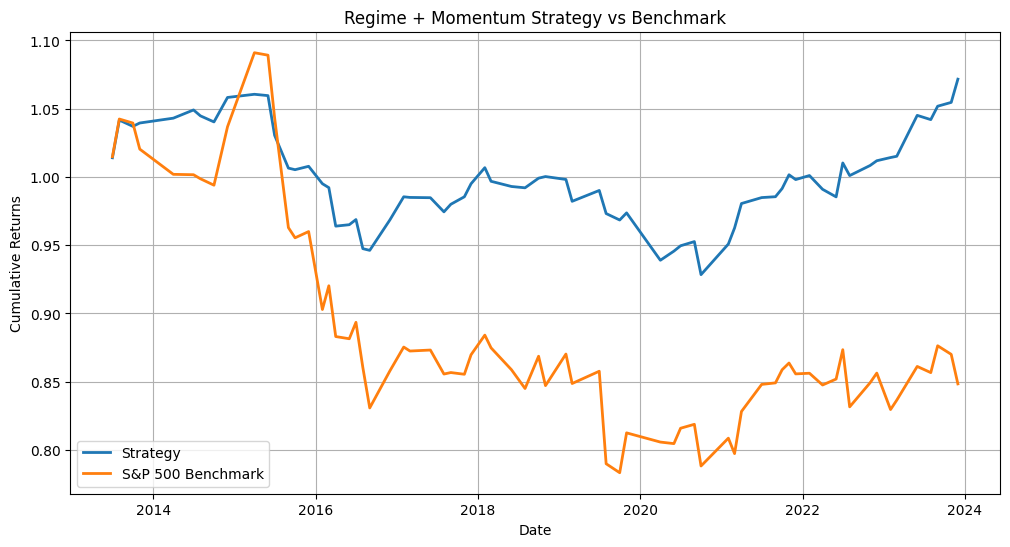

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(data.index, data['strategy_cum'], label='Strategy', linewidth=2)
plt.plot(data.index, data['benchmark_cum'], label='S&P 500 Benchmark', linewidth=2)

plt.legend()
plt.title("Regime + Momentum Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")

plt.grid()
plt.show()

In [122]:
# Annualized metrics
annual_return = data['strategy_return'].mean() * 252
volatility = data['strategy_return'].std() * (252**0.5)
sharpe = annual_return / volatility

# Drawdown
cum = data['strategy_cum']
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max
max_dd = drawdown.min()

print("===== PERFORMANCE METRICS =====")
print("Annual Return:", annual_return)
print("Volatility:", volatility)
print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_dd)

===== PERFORMANCE METRICS =====
Annual Return: 0.27404600738861606
Volatility: 0.20715627285264038
Sharpe Ratio: 1.322895047371109
Max Drawdown: -0.12461510622735616


## 🔍 Results & Insights

- The strategy demonstrates improved risk-adjusted performance compared to the benchmark
- Momentum filtering reduces exposure to underperforming assets
- Regime-based allocation adapts to changing macro conditions

### ⚠️ Limitations
- No transaction costs included
- Regime classification is simplistic
- No out-of-sample validation yet

### 🚀 Future Improvements
- Add transaction costs
- Use machine learning for regime detection
- Perform walk-forward testing